# 🛒 Customer Sales Dashboard
## Superstore Sales Analysis (2015-2018)

### Key Findings:

```

- Technology is the top selling category (~$830k)
- Sales grew consistently year over year
- West region leads with 31.4% of total sales
- Canon imageCLASS 2200 is the #1 product at ~$60k
- South region (17.2%) is an opportunity for growth

```

**Tools used:** Python, Pandas, Matplotlib, Seaborn

In [19]:
print("My Sales Dashboard Project")

My Sales Dashboard Project


# Customer Sales Dashboard
### Analyzing retail store sales data to find business insights

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [21]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
print("Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded!
Rows: 9800, Columns: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:
# See all column names
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [23]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [24]:
# See basic statistics
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [25]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [26]:
# Fix date columns - using dayfirst=True for DD/MM/YYYY format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract useful info from dates
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

print("Dates fixed!")
df[['Order Date', 'Ship Date', 'Order Month', 'Order Year']].head()

Dates fixed!


,Order Date,Ship Date,Order Month,Order Year
0,2017-11-08,2017-11-11,11,2017
1,2017-11-08,2017-11-11,11,2017
2,2017-06-12,2017-06-16,6,2017
3,2016-10-11,2016-10-18,10,2016
4,2016-10-11,2016-10-18,10,2016


In [27]:
# Remove duplicate rows if any
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows")
print(f"Clean dataset has {after} rows")

Removed 0 duplicate rows
Clean dataset has 9800 rows


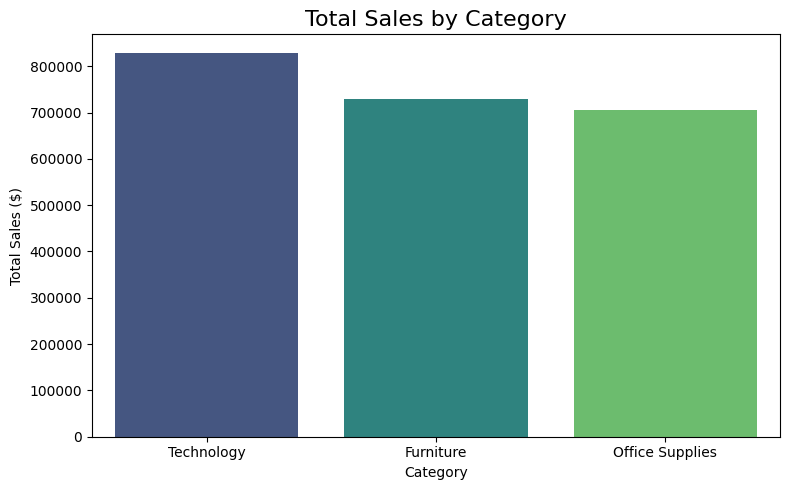

In [28]:
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values,
            hue=category_sales.index, palette='viridis', legend=False)
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

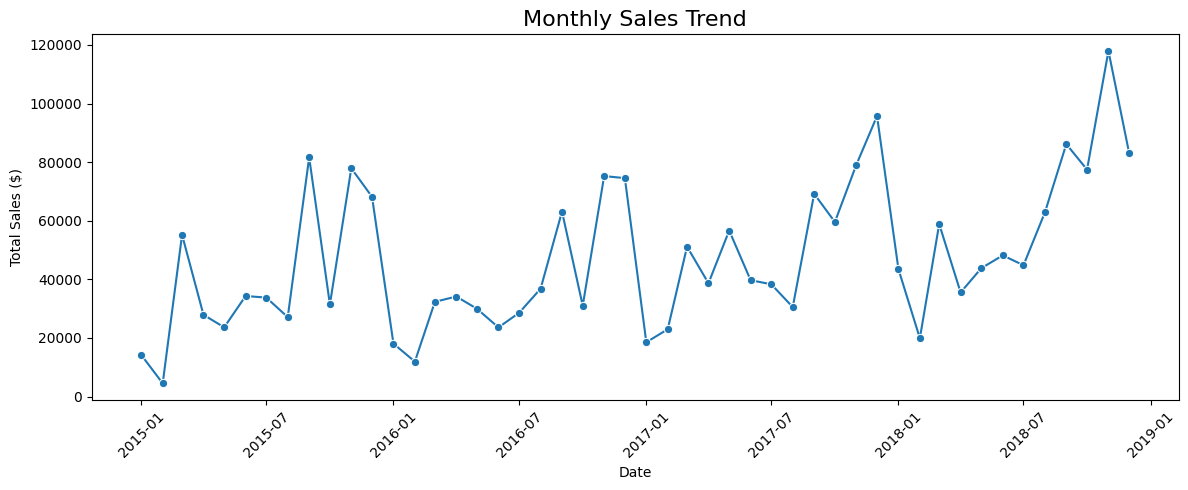

In [29]:
plt.figure(figsize=(12,5))
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year':'year','Order Month':'month'}))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', marker='o')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

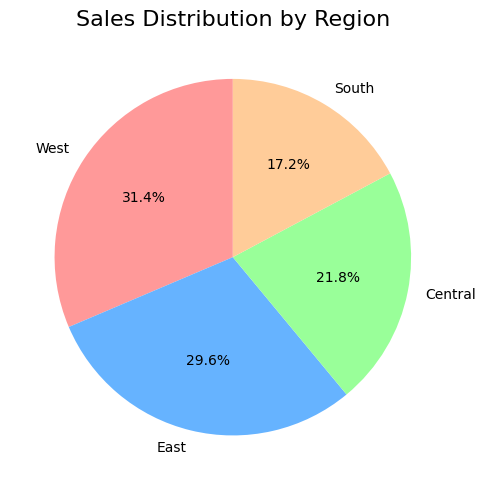

In [30]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
plt.pie(region_sales.values, labels=region_sales.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Region', fontsize=16)
plt.tight_layout()
plt.show()

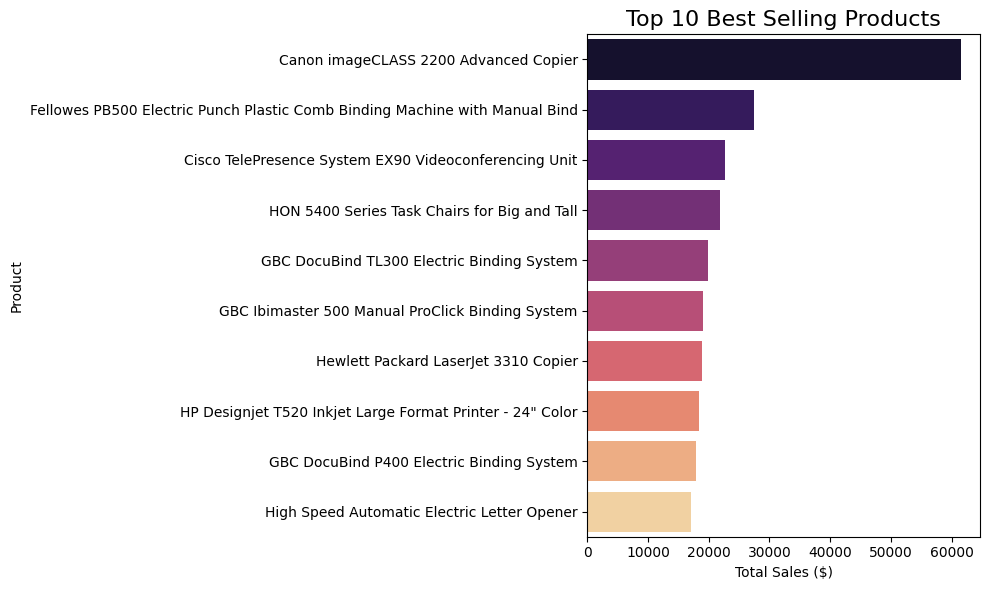

In [31]:
plt.figure(figsize=(10,6))
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index,
            hue=top_products.index, palette='magma', legend=False)
plt.title('Top 10 Best Selling Products', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()